In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('superstore_cleaned.csv')
print("Data loaded:", df.shape)

Data loaded: (9993, 20)


In [2]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9993.000000,9993.000000,9993.000000,9993.000000,9993.000000
mean,55191.576403,229.852846,3.789753,0.156188,28.660971
std,32065.074478,623.276074,2.225149,0.206457,234.271476
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.731000
50%,56560.000000,54.480000,3.000000,0.200000,8.671000
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [3]:
print("Region:", df['Region'].unique())
print("Category:", df['Category'].unique())
print("Segment:", df['Segment'].unique())
print("Ship Mode:", df['Ship Mode'].unique())

Region: ['South' 'West' 'Central' 'East']
Category: ['Furniture' 'Office Supplies' 'Technology']
Segment: ['Consumer' 'Corporate' 'Home Office']
Ship Mode: ['Second Class' 'Standard Class' 'First Class' 'Same Day']


In [4]:
print(df['Category'].value_counts())

Category
Office Supplies    6026
Furniture          2120
Technology         1847
Name: count, dtype: int64


In [5]:
kategori = df.groupby('Category')[['Sales', 'Profit']].sum().round(2)
print(kategori)

                     Sales     Profit
Category                             
Furniture        741718.42   18463.33
Office Supplies  719047.03  122490.80
Technology       836154.03  145454.95


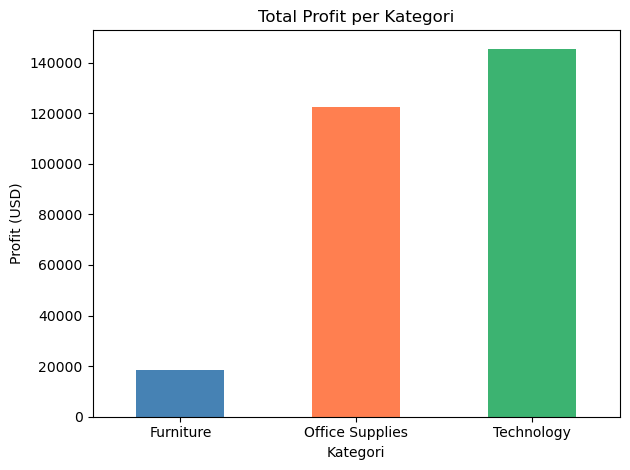

In [6]:
kategori['Profit'].plot(kind='bar', color=['steelblue', 'coral', 'mediumseagreen'])
plt.title('Total Profit per Kategori')
plt.xlabel('Kategori')
plt.ylabel('Profit (USD)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

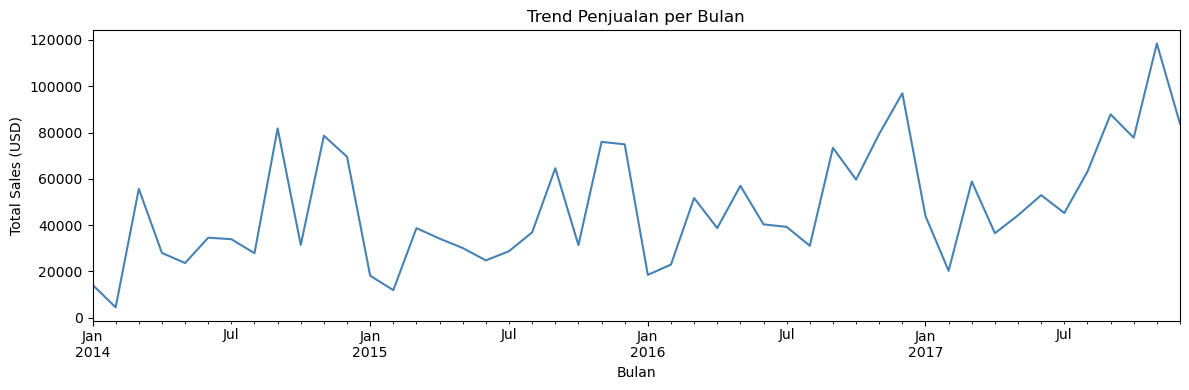

In [7]:
# Pastikan Order Date sudah datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Order Month'] = df['Order Date'].dt.to_period('M')

bulanan = df.groupby('Order Month')['Sales'].sum()
bulanan.plot(kind='line', figsize=(12, 4), color='steelblue')
plt.title('Trend Penjualan per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Total Sales (USD)')
plt.tight_layout()
plt.show()

Region
West       108418.4489
East        91534.8388
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64


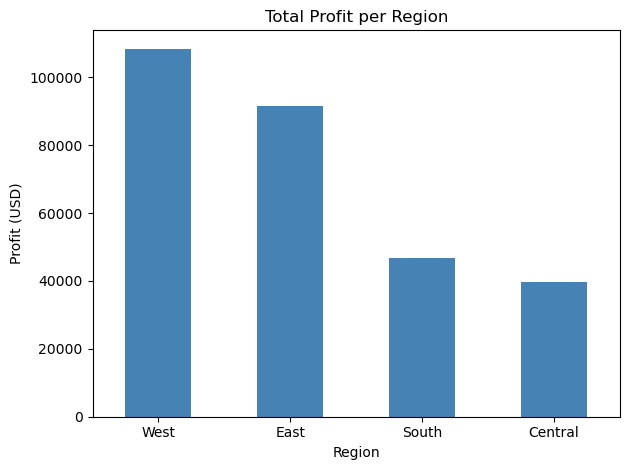

In [8]:
region = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
print(region)

region.plot(kind='bar', color='steelblue')
plt.title('Total Profit per Region')
plt.xlabel('Region')
plt.ylabel('Profit (USD)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Discount Group
0-10%      96.06
10-30%     20.69
30-50%   -156.28
50%+      -89.44
Name: Profit, dtype: float64


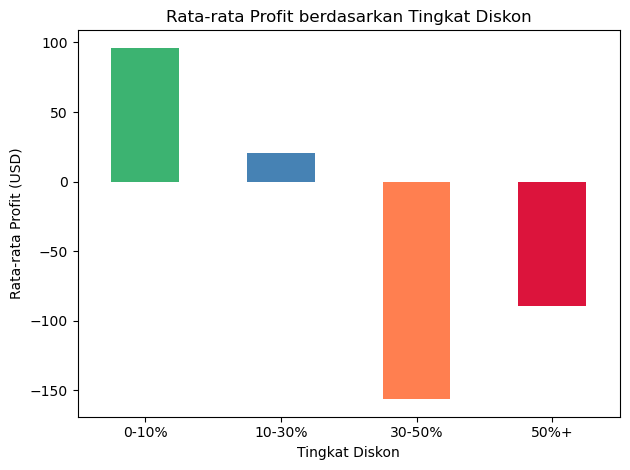

In [9]:
# Kelompokkan diskon ke dalam bucket
df['Discount Group'] = pd.cut(df['Discount'], 
                               bins=[0, 0.1, 0.3, 0.5, 1.0],
                               labels=['0-10%', '10-30%', '30-50%', '50%+'])

diskon = df.groupby('Discount Group', observed=True)['Profit'].mean().round(2)
print(diskon)

diskon.plot(kind='bar', color=['mediumseagreen', 'steelblue', 'coral', 'crimson'])
plt.title('Rata-rata Profit berdasarkan Tingkat Diskon')
plt.xlabel('Tingkat Diskon')
plt.ylabel('Rata-rata Profit (USD)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Sub-Category
Tables      -17725.4811
Bookcases    -3472.5560
Supplies     -1189.0995
Fasteners      949.5182
Machines      3384.7569
Name: Profit, dtype: float64


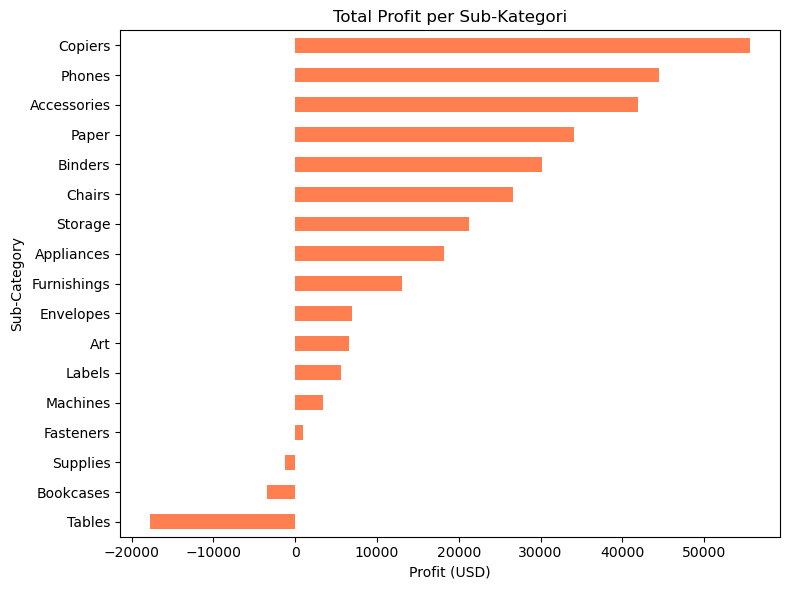

In [10]:
subkat = df.groupby('Sub-Category')['Profit'].sum().sort_values()
print(subkat.head(5))  # 5 paling rugi

subkat.plot(kind='barh', figsize=(8, 6), color='coral')
plt.title('Total Profit per Sub-Kategori')
plt.xlabel('Profit (USD)')
plt.tight_layout()
plt.show()

In [11]:
print("=== RINGKASAN INSIGHT ===")
print(f"\n1. Kategori paling profitable:")
print(df.groupby('Category')['Profit'].sum().sort_values(ascending=False).head(1))

print(f"\n2. Region paling profitable:")
print(df.groupby('Region')['Profit'].sum().sort_values(ascending=False).head(1))

print(f"\n3. Sub-kategori paling rugi:")
print(df.groupby('Sub-Category')['Profit'].sum().sort_values().head(1))

print(f"\n4. Jumlah transaksi rugi:")
rugi = df[df['Profit'] < 0]
print(f"   {len(rugi)} transaksi ({len(rugi)/len(df)*100:.1f}% dari total)")

=== RINGKASAN INSIGHT ===

1. Kategori paling profitable:
Category
Technology    145454.9481
Name: Profit, dtype: float64

2. Region paling profitable:
Region
West    108418.4489
Name: Profit, dtype: float64

3. Sub-kategori paling rugi:
Sub-Category
Tables   -17725.4811
Name: Profit, dtype: float64

4. Jumlah transaksi rugi:
   1870 transaksi (18.7% dari total)


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('superstore_cleaned.csv')
print("Data loaded:", df.shape)

Data loaded: (9993, 20)


In [3]:
furniture = df[df['Category'] == 'Furniture'].groupby('Sub-Category')[['Sales', 'Profit']].sum().round(2)
print(furniture)

                  Sales    Profit
Sub-Category                     
Bookcases     114880.00  -3472.56
Chairs        328167.73  26602.23
Furnishings    91705.16  13059.14
Tables        206965.53 -17725.48


In [4]:
diskon_besar = df[df['Discount'] >= 0.3]
print("Jumlah transaksi diskon 30%+:", len(diskon_besar))
print("\nPer kategori:")
print(diskon_besar['Category'].value_counts())
print("\nPer region:")
print(diskon_besar['Region'].value_counts())

Jumlah transaksi diskon 30%+: 1392

Per kategori:
Category
Office Supplies    680
Furniture          541
Technology         171
Name: count, dtype: int64

Per region:
Region
Central    643
East       460
South      171
West       118
Name: count, dtype: int64


In [5]:
west = df[df['Region'] == 'West'].groupby('Category')[['Sales', 'Profit']].sum().round(2)
print(west)

                     Sales    Profit
Category                            
Furniture        252612.74  11504.95
Office Supplies  220853.25  52609.85
Technology       251991.83  44303.65


Ship Mode
Same Day          0.0
First Class       2.2
Second Class      3.2
Standard Class    5.0
Name: Shipping Days, dtype: float64


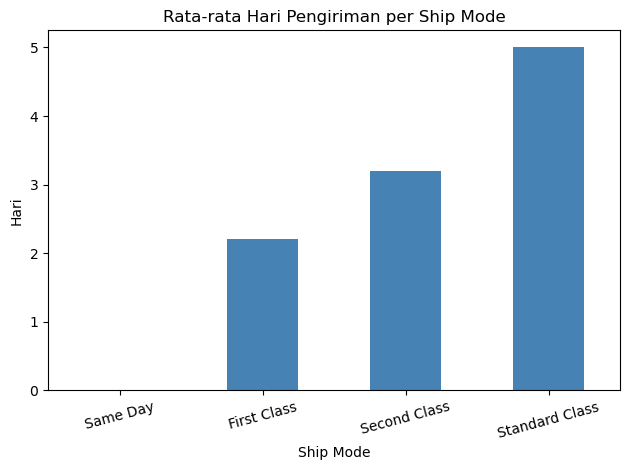

In [6]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

shipping = df.groupby('Ship Mode')['Shipping Days'].mean().round(1).sort_values()
print(shipping)

shipping.plot(kind='bar', color='steelblue')
plt.title('Rata-rata Hari Pengiriman per Ship Mode')
plt.xlabel('Ship Mode')
plt.ylabel('Hari')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [7]:
print("=" * 45)
print("RINGKASAN INSIGHT SUPERSTORE")
print("=" * 45)

print("\n📦 KATEGORI")
for cat, row in df.groupby('Category')[['Sales','Profit']].sum().iterrows():
    margin = row['Profit'] / row['Sales'] * 100
    print(f"  {cat:<18} margin: {margin:.1f}%")

print("\n🌍 REGION TERBAIK")
print(" ", df.groupby('Region')['Profit'].sum().idxmax(), 
      "→ $" + str(round(df.groupby('Region')['Profit'].sum().max(), 0)))

print("\n⚠️  SUB-KATEGORI BERMASALAH")
rugi_subkat = df.groupby('Sub-Category')['Profit'].sum().sort_values().head(3)
for subkat, profit in rugi_subkat.items():
    print(f"  {subkat:<20} ${profit:,.0f}")

print("\n💸 DAMPAK DISKON BESAR (>=30%)")
rugi_diskon = df[df['Discount'] >= 0.3]['Profit'].sum()
print(f"  Total kerugian: ${rugi_diskon:,.0f}")

print("\n📊 TOTAL TRANSAKSI RUGI")
print(f"  {len(df[df['Profit']<0])} transaksi ({len(df[df['Profit']<0])/len(df)*100:.1f}%)")
print("=" * 45)

RINGKASAN INSIGHT SUPERSTORE

📦 KATEGORI
  Furniture          margin: 2.5%
  Office Supplies    margin: 17.0%
  Technology         margin: 17.4%

🌍 REGION TERBAIK
  West → $108418.0

⚠️  SUB-KATEGORI BERMASALAH
  Tables               $-17,725
  Bookcases            $-3,473
  Supplies             $-1,189

💸 DAMPAK DISKON BESAR (>=30%)
  Total kerugian: $-135,364

📊 TOTAL TRANSAKSI RUGI
  1870 transaksi (18.7%)


In [8]:
# Simpan ringkasan per kategori
kategori_summary = df.groupby('Category')[['Sales', 'Profit']].sum().round(2)
kategori_summary['Margin %'] = (kategori_summary['Profit'] / kategori_summary['Sales'] * 100).round(1)
kategori_summary.to_csv('output_kategori.csv')

# Simpan ringkasan per region
region_summary = df.groupby('Region')[['Sales', 'Profit']].sum().round(2)
region_summary.to_csv('output_region.csv')

# Simpan transaksi rugi
df[df['Profit'] < 0].to_csv('output_transaksi_rugi.csv', index=False)

# Simpan data diskon besar
df[df['Discount'] >= 0.3].to_csv('output_diskon_besar.csv', index=False)

print("Semua output tersimpan!")
print("\nFile yang dibuat:")
print("- output_kategori.csv")
print("- output_region.csv")
print("- output_transaksi_rugi.csv")
print("- output_diskon_besar.csv")

Semua output tersimpan!

File yang dibuat:
- output_kategori.csv
- output_region.csv
- output_transaksi_rugi.csv
- output_diskon_besar.csv
